# Sulfur_X Workflow

### Import Python Libraries

In [1]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

### Enter Initial and Basic Parameters Below

In [2]:
# Temperature in C
temperature = 1030

# fO2 relative to FMQ buffer
delta_FMQ = 1.2

# initial H2O in wt.%
H2O_initial = 4.5

# initial CO2 in ppm
CO2_initial = 3300

# initial sulfur in ppm
S_initial = 2650

# Enable crystallization (yes=1,no=0)
crystallize = 1

# The total steps of pressure from initial P to 1 bar.
l = 1000

# Total number of runs along degassing
m = 1000

### Specify models to use and tracking

In [3]:
# Which COH degassing model to use? 1 for VolatileCalc; 0 for Iacono_Marziano model
COH_model = 0

# Which S speciation model to use? 0 for Nash model; 1 for O'Neill and Mavrogenes (2022) model; 100 for Muth model
S_Fe_choice = 0

# Changing fO2 or not? If 1, fO2 changes by S degassing and S-Fe electron exchange;
# if 0, fO2 if buffered at the delta_FMQ
fo2_tracker = 1

### Enter Filenames

In [4]:
#Melt inclusion data file (.csv)
mi_name = "./src/Fuego.csv"

# Output file
output_name = f"Fuego_crystallization_{S_Fe_choice}.csv"

#Save plot images? (True/False)
save_img = True

### Specify use of Monte Carlo

In [5]:
# Use monte carlo simulation for error estimate? (1/0)
# If 1, input number of runs, otherwise ignore

monte_carlo = 0

mc_runs = 0

### Set melt fraction and low pressure parameters

In [6]:
# Decimal value between 0 and 1, percentage of melt
melt_fraction = 1

INC = 20

BAR = 0

### Enter advanced inputs

In [7]:
#Dulfide composition in wt%, only relevant if SCSS is of interest
sulfide = {"Fe": 65.43,
            "Ni": 0,
            "Cu": 0,
            "O": 0,
            "S": 36.47
            }

# Tolerance (sigma) of log_10(fO2)
sigma = .005

# if crystallization is enabled, H2O-melt fraction relation is specified using H2O-K2O relation (K2O = a * H2O +b),
# assuming K2O is perfectly incompatible. The given a and b are based on H2O-K2O relation for Fuego magma from
# Lloyd et al. (2013). Both H2O and K2O are in wt.%. If crystallization is disabled, or running on magmas similar to Fuego,
# leave them unchanged.
slope_h2o = -0.713

constant_h2o = 3.689

In [8]:
f = open("./src/main_Fuego.py","r+")
main = f.readlines()
main[27] = f"""temperature = {temperature}\n"""
main[30] = f"""delta_FMQ = {delta_FMQ}\n"""
main[32] = f"""H2O_initial = {H2O_initial}\n"""
main[34] = f"""CO2_initial = {CO2_initial}\n"""
main[40] = f"""choice = {crystallize}\n"""
main[42] = f"""COH_model = {COH_model}\n"""
main[45] = f"""fo2_tracker = {fo2_tracker}\n"""
main[49] = f"""monte_carlo = {monte_carlo}\n"""
main[52] = f"""    m_run = {mc_runs}\n"""
main[58] = f"""l = {l}\n"""
main[60] = f"""m = {m}\n"""
main[63] = f"""sulfide = {{"Fe": {sulfide["Fe"]},\n"""
main[64] = f"""    "Ni": {sulfide["Ni"]},\n"""
main[65] = f"""    "Cu": {sulfide["Cu"]},\n"""
main[66] = f"""    "O": {sulfide["O"]},\n"""
main[67] = f"""    "S": {sulfide["S"]},\n"""
main[68] = f"""    }}\n"""
main[81] = f"""S_Fe_choice = {S_Fe_choice}\n"""
main[84] = f"""sigma = {sigma}\n"""
main[90] = f"""slope_h2o = {slope_h2o}\n"""
main[91] = f"""constant_h2o = {constant_h2o}\n"""
main[98] = f"""mi_name = '{mi_name}'\n"""
main[101] = f"""output_name = 'Fuego_crystallization_{S_Fe_choice}.csv'\n"""
main[117] = f"""melt_comp_initial = MeltComposition(melt_fraction={melt_fraction}, choice={crystallize})\n"""
f.seek(0)
f.writelines(main)
f.truncate()
f.close()

g = open("./src/degassingrun.py","r+")
degas = g.readlines()
degas[13] = f"""INC = {INC}\n"""
degas[14] = f"""BAR = {BAR}\n"""
main[32] = f"""        self.sulfide = {{"Fe": {sulfide["Fe"]},\n"""
main[33] = f"""                        "Ni": {sulfide["Ni"]},\n"""
main[34] = f"""                        "Cu": {sulfide["Cu"]},\n"""
main[35] = f"""                        "O": {sulfide["O"]},\n"""
main[36] = f"""                        "S": {sulfide["S"]},\n"""
main[37] = f"""                        }}\n"""
g.seek(0)
g.writelines(degas)
g.truncate()
g.close()


 The initial vapor saturation pressure is 4241.375892193157 bar, and the initial vapor concentration is XH2O = 0.43689711935312003 and XCO2 = 0.56310288064688.
0.27537389896510295
0.8636621167852134
0.0
Montecarlo simulation


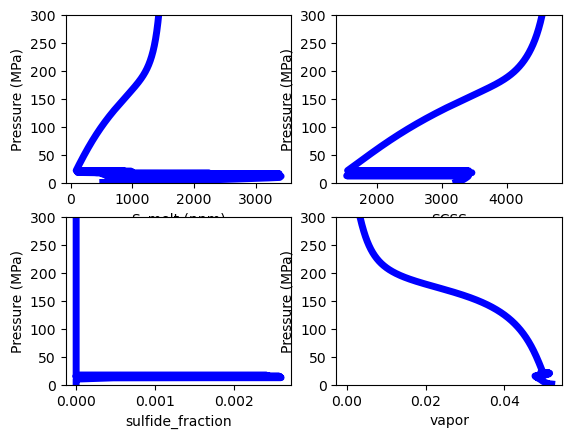

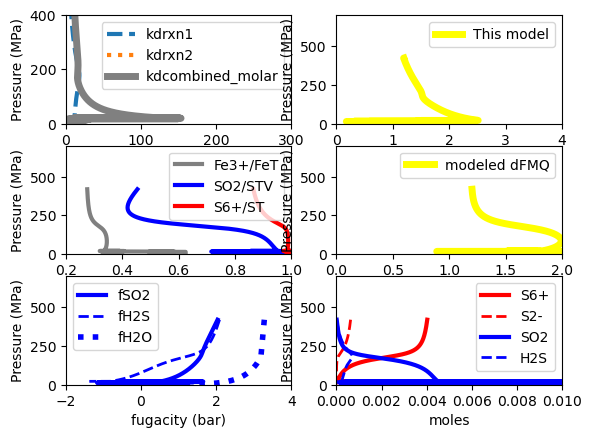

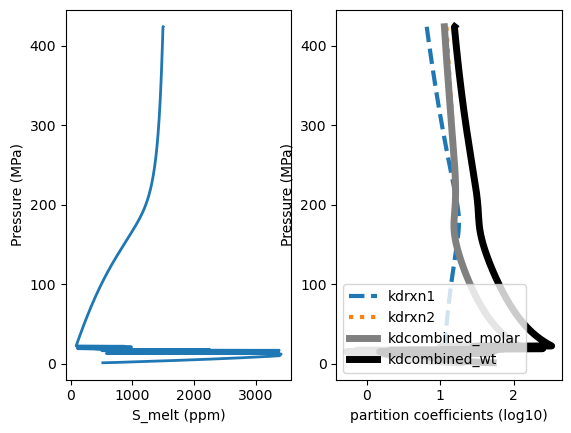

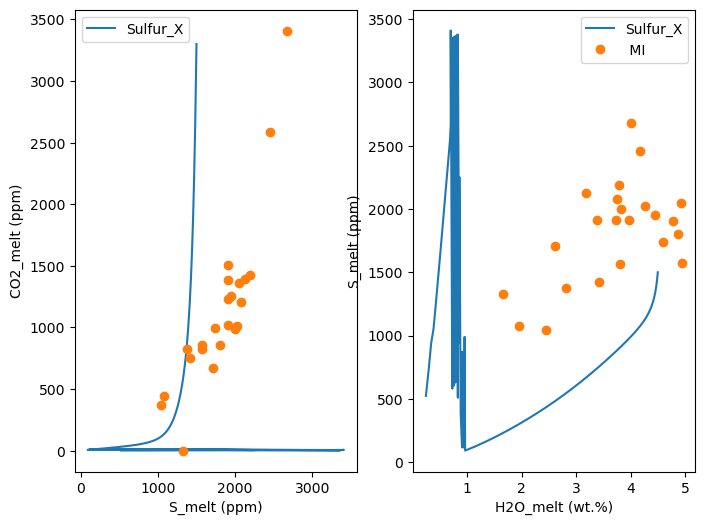

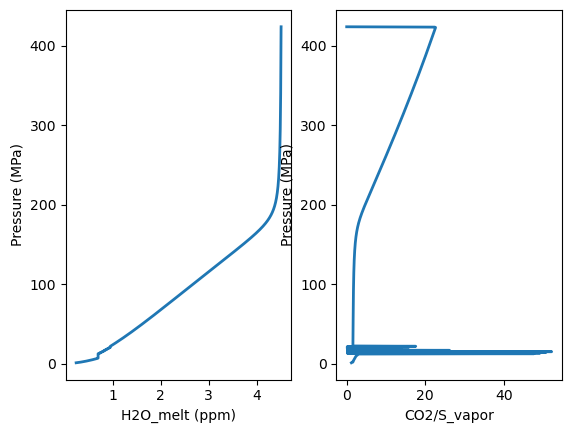

In [9]:
%run "./src/main_Fuego.py"